# 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
import joblib
import shap

d:\anaconda3\envs\ml-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Load Processed Data

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((88416, 24), (22105, 24), (88416, 1), (22105, 1))

# 3. Convert Target to Series

In [3]:
y_train = y_train['No-show']
y_test = y_test['No-show']
y_train.shape, y_test.shape

((88416,), (22105,))

# 4. Logistic Regression

### 4.1 Feature Scaling
Logistic Regression is scale-sensitive, so features are standardized before training.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4.2 Training

In [5]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 4.3 Evaluation

In [6]:
y_pred_log = log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.87      0.67      0.76     17642
           1       0.31      0.60      0.41      4463

    accuracy                           0.65     22105
   macro avg       0.59      0.63      0.58     22105
weighted avg       0.76      0.65      0.69     22105



### 4.4 Confusion Matrix

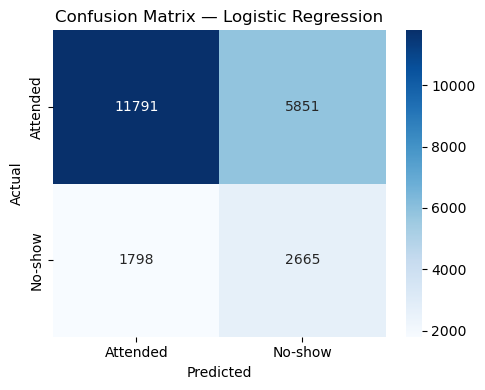

In [7]:
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attended', 'No-show'], yticklabels=['Attended', 'No-show'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
plt.close()

# 5. Decision Tree

### 5.1 Training

In [8]:
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


### 5.2 Evaluation

In [9]:
y_pred_dt = dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.92      0.52      0.67     17642
           1       0.31      0.83      0.45      4463

    accuracy                           0.59     22105
   macro avg       0.61      0.68      0.56     22105
weighted avg       0.80      0.59      0.62     22105



### 5.3 Confusion Matrix

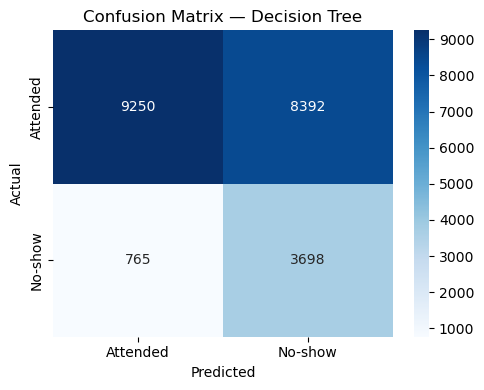

In [10]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attended', 'No-show'], yticklabels=['Attended', 'No-show'])
plt.title('Confusion Matrix — Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
plt.close()

### 5.4 Interim Comparison — Logistic Regression vs Decision Tree
- Logistic Regression: Accuracy 0.65, Recall (no-show) 0.60, Precision (no-show) 0.31
- Decision Tree: Accuracy 0.59, Recall (no-show) 0.83, Precision (no-show) 0.31
- Decision Tree shows higher recall for the no-show class, which aligns better with the business goal of catching as many potential no-shows as possible.
- Both models suffer from low precision, indicating a high false-positive rate — this will be assessed against the ensemble models next.

# 6. Random Forest

### 6.1 Training

In [11]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 6.2 Evaluation

In [12]:
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.56      0.70     17642
           1       0.32      0.80      0.45      4463

    accuracy                           0.61     22105
   macro avg       0.62      0.68      0.57     22105
weighted avg       0.80      0.61      0.65     22105



### 6.3 Confusion Matrix

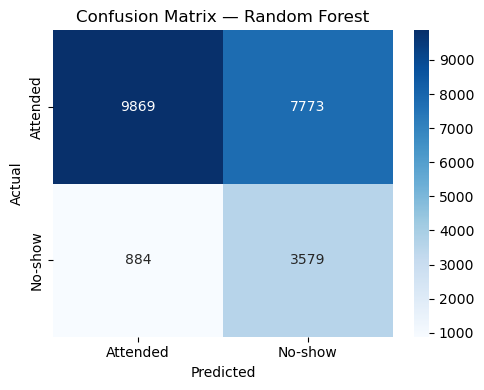

In [13]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attended', 'No-show'], yticklabels=['Attended', 'No-show'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
plt.close()

# 7. XGBoost

### 7.1 Training

In [14]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=200, max_depth=6, scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### 7.2 Evaluation

In [15]:
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.63      0.74     17642
           1       0.33      0.71      0.45      4463

    accuracy                           0.65     22105
   macro avg       0.61      0.67      0.59     22105
weighted avg       0.78      0.65      0.68     22105



### 7.3 Confusion Matrix

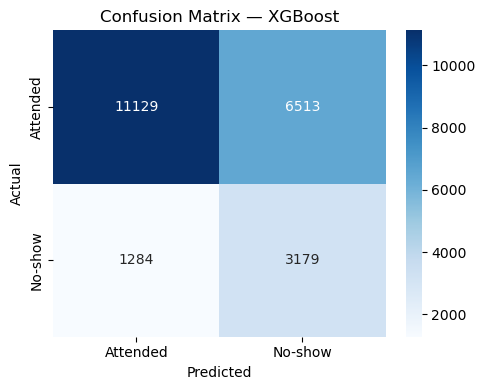

In [16]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attended', 'No-show'], yticklabels=['Attended', 'No-show'])
plt.title('Confusion Matrix — XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
plt.close()

# 8. Confusion Matrices — Side-by-Side Comparison

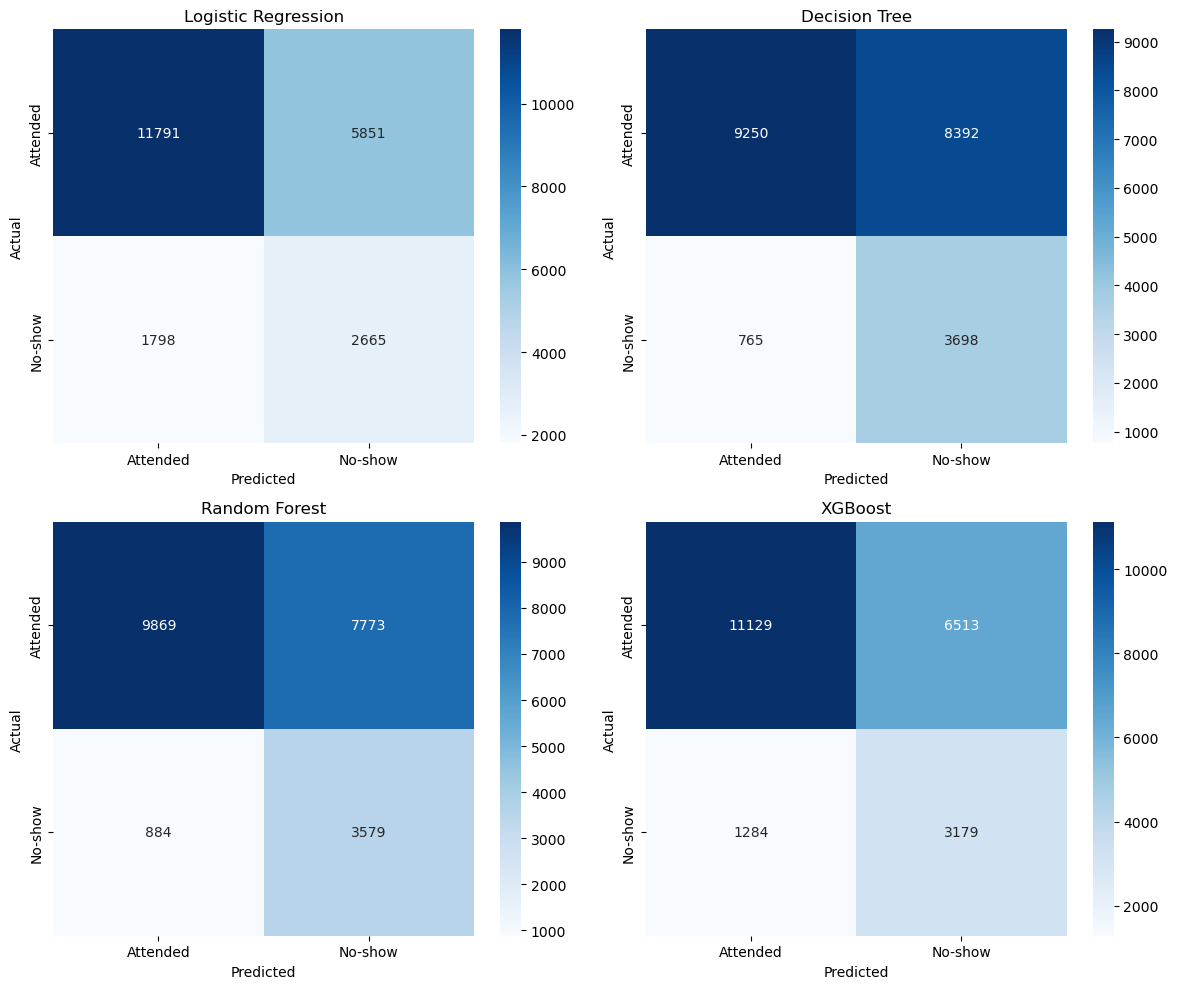

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_preds = {
    'Logistic Regression': y_pred_log,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

for ax, (name, preds) in zip(axes.flatten(), models_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Attended', 'No-show'], yticklabels=['Attended', 'No-show'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()
plt.close()

# 9. ROC-AUC Comparison

In [18]:
print("Logistic Regression:", roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1]))
print("Decision Tree:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))
print("Random Forest:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print("XGBoost:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

Logistic Regression: 0.6788210222773384
Decision Tree: 0.7341955762026044
Random Forest: 0.7403455328566211
XGBoost: 0.7359220301155835


# 10. ROC Curve — All Models

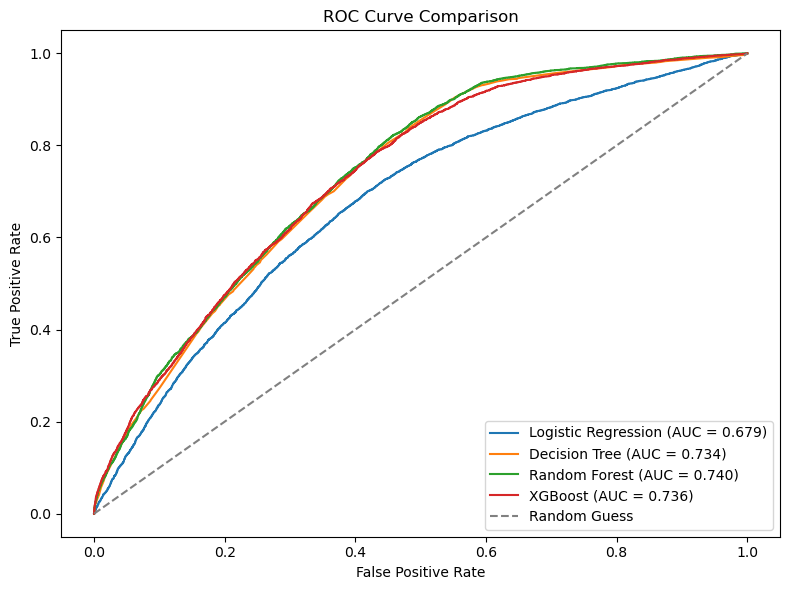

In [19]:
plt.figure(figsize=(8, 6))

models_proba = {
    'Logistic Regression': log_reg.predict_proba(X_test_scaled)[:, 1],
    'Decision Tree': dt.predict_proba(X_test)[:, 1],
    'Random Forest': rf.predict_proba(X_test)[:, 1],
    'XGBoost': xgb.predict_proba(X_test)[:, 1]
}

for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.close()

# 11. Model Comparison — Table & Charts

In [20]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.65, 0.59, 0.61, 0.65],
    'Precision': [0.31, 0.31, 0.32, 0.33],
    'Recall': [0.60, 0.83, 0.80, 0.71],
    'F1_Score': [0.41, 0.45, 0.45, 0.45],
    'ROC_AUC': [0.679, 0.734, 0.740, 0.736]
})
model_comparison

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.65,0.31,0.60,0.41,0.679
1,Decision Tree,0.59,0.31,0.83,0.45,0.734
2,Random Forest,0.61,0.32,0.80,0.45,0.740
3,XGBoost,0.65,0.33,0.71,0.45,0.736


### 11.1 Metrics Comparison Chart

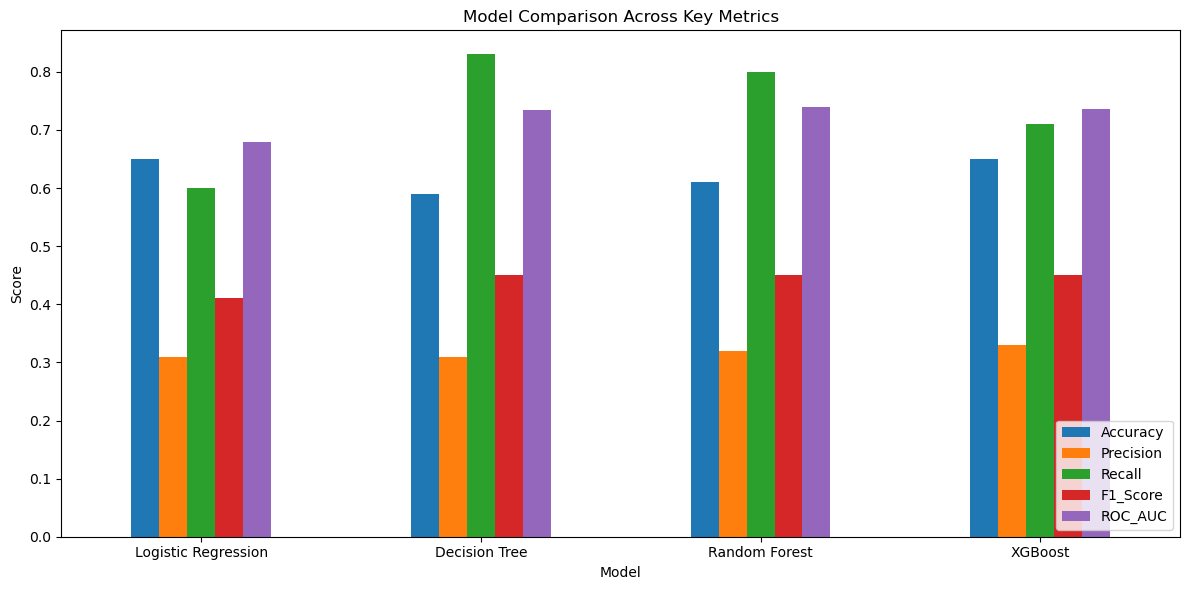

In [21]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']

fig, ax = plt.subplots(figsize=(12, 6))
model_comparison.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=ax)
plt.title('Model Comparison Across Key Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.close()

### 11.2 ROC-AUC Highlight (Most Reliable Metric)

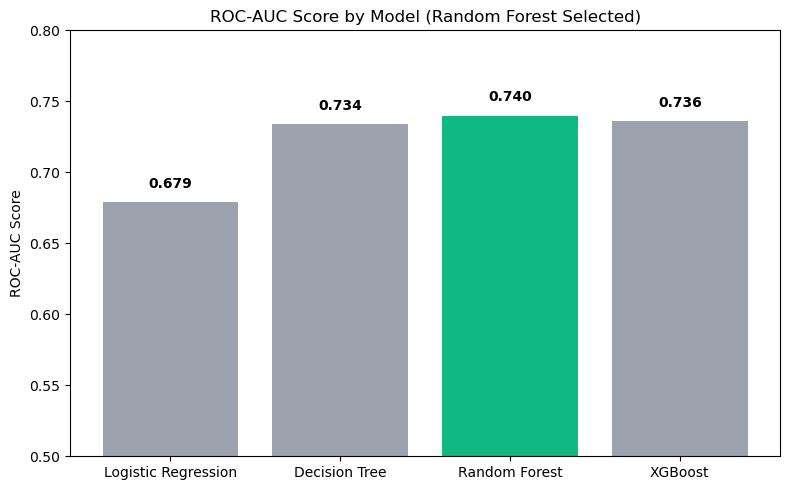

In [22]:
plt.figure(figsize=(8, 5))
colors = ['#9CA3AF' if model != 'Random Forest' else '#10B981' for model in model_comparison['Model']]
plt.bar(model_comparison['Model'], model_comparison['ROC_AUC'], color=colors)
plt.title('ROC-AUC Score by Model (Random Forest Selected)')
plt.ylabel('ROC-AUC Score')
plt.ylim(0.5, 0.8)
for i, v in enumerate(model_comparison['ROC_AUC']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

### 11.3 Precision-Recall Trade-off (No-show Class)

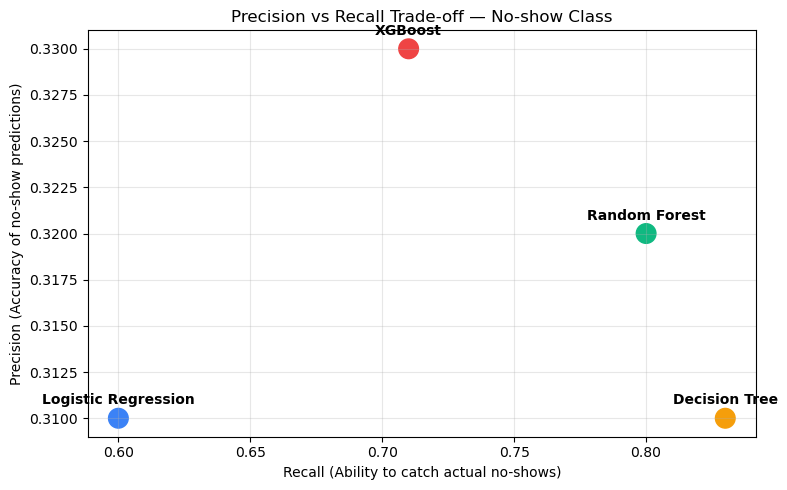

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(model_comparison['Recall'], model_comparison['Precision'], s=200, c=['#3B82F6', '#F59E0B', '#10B981', '#EF4444'])

for i, model in enumerate(model_comparison['Model']):
    plt.annotate(model, (model_comparison['Recall'][i], model_comparison['Precision'][i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold')

plt.title('Precision vs Recall Trade-off — No-show Class')
plt.xlabel('Recall (Ability to catch actual no-shows)')
plt.ylabel('Precision (Accuracy of no-show predictions)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# 12. Cross-Validation — Random Forest Stability Check

In [24]:
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

print("CV ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

CV ROC-AUC scores: [0.74406664 0.74358962 0.74140801 0.74133331 0.74221853]
Mean ROC-AUC: 0.7425232193991574
Std Dev: 0.0011199795226512004


Cross-validation confirms stability: mean ROC-AUC of 0.7425 (std dev 0.0011) closely matches the single train-test split result (0.740), indicating the model's performance is consistent and not dependent on a particular data split.

# 13. Final Model Selection

Random Forest is selected as the final model based on:
- Highest ROC-AUC score (0.740) among all models tested, confirmed stable via 5-fold cross-validation
- Strong recall (0.80) for the no-show class, aligning with the business priority of catching potential no-shows
- Tree-based structure enables clean SHAP explainability

# 14. Feature Importance — Random Forest (Final Model)

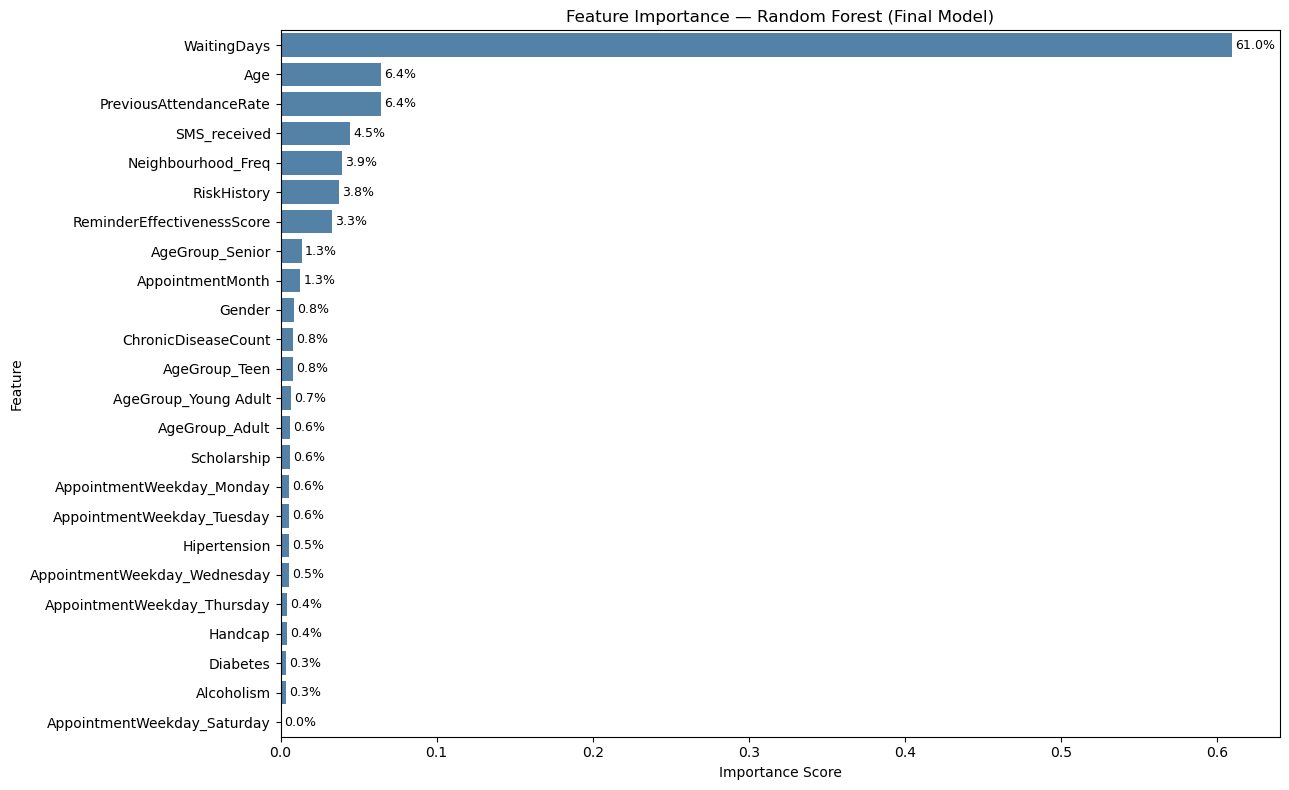

In [25]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

importance_df['Importance_Pct'] = importance_df['Importance'] * 100

plt.figure(figsize=(13, 8))
ax = sns.barplot(data=importance_df, x='Importance', y='Feature', color='steelblue')

for i, (importance, pct) in enumerate(zip(importance_df['Importance'], importance_df['Importance_Pct'])):
    ax.text(importance + 0.002, i, f"{pct:.1f}%", va='center', fontsize=9)

plt.title('Feature Importance — Random Forest (Final Model)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
plt.close()

# 15. SHAP Explainability

### 15.1 Compute SHAP Values

In [26]:
X_sample = X_test.sample(500, random_state=42)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

### 15.2 SHAP Summary Plot (Global Feature Impact)

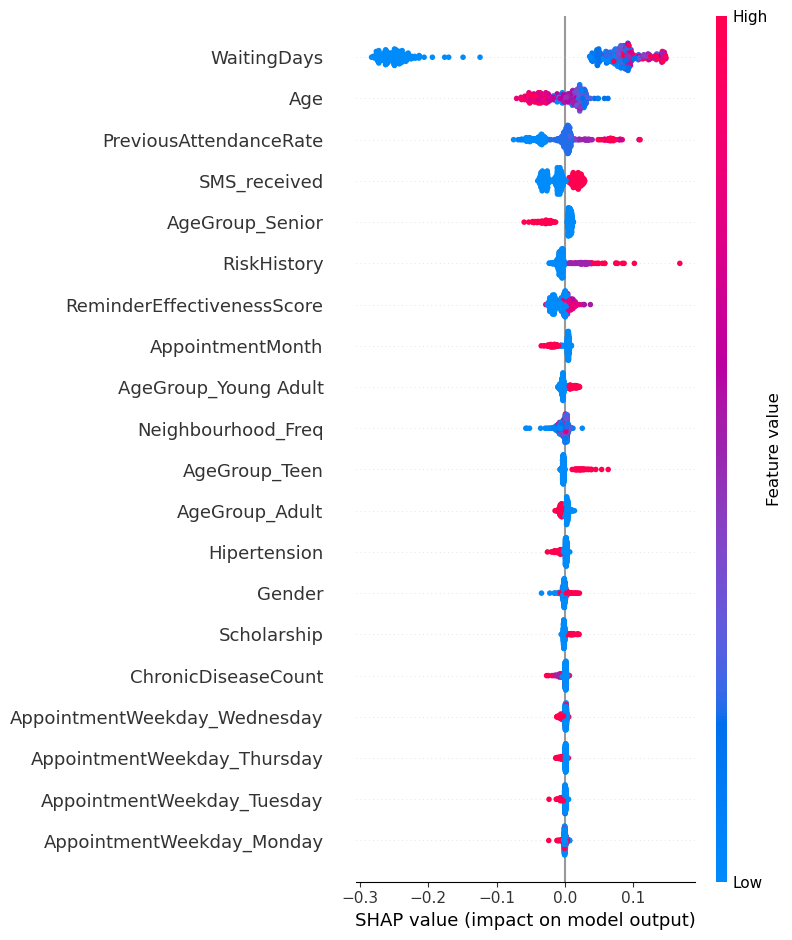

In [27]:
shap.summary_plot(shap_values[:, :, 1], X_sample)

### 15.3 SHAP Force Plot (Single Prediction Explanation)

In [28]:
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[0, :, 1], X_sample.iloc[0])

# 16. Save Final Model (Random Forest)

In [29]:
joblib.dump(rf, "../models/final_pipeline.joblib")

['../models/final_pipeline.joblib']

# Conclusion

- 4 models trained and compared: Logistic Regression, Decision Tree, Random Forest, XGBoost
- Random Forest selected as final model — highest ROC-AUC (0.740), confirmed stable via 5-fold cross-validation (mean 0.7425, std dev 0.0011)
- Accuracy alone was not used as the deciding metric due to ~80/20 class imbalance; recall on the no-show class was prioritized
- WaitingDays is the dominant predictor (61% feature importance), consistent across both feature_importances_ and SHAP analysis
- RiskHistory had lower-than-expected impact (~3.8%) due to its highly skewed distribution in the training data — verified this wasn't a model defect by testing other strong features independently
- SHAP explainability integrated for both global feature impact and individual prediction transparency
- Final model and supporting artifacts (neighbourhood frequency map, feature column order) saved for use in the FastAPI serving layer